In [2]:
# Установка необходимых библиотек (если ещё не установлены)
!pip install pmdarima statsmodels scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import pmdarima as pm
from scipy.stats import boxcox
from scipy.special import inv_boxcox

# Загрузка файла вручную (в Colab нужно нажать на кнопку загрузки)
from google.colab import files
uploaded = files.upload()

# Чтение данных
df = pd.read_csv('US_renewable_energy_consumption.csv')
df['date'] = pd.to_datetime(df['date'])
df.sort_values('date', inplace=True)

# Агрегация: сумма потребления по всем секторам и типам энергии для каждого месяца
total = df.groupby('date')['value_trillion_btu'].sum().reset_index()
total.columns = ['date', 'total_consumption']
total.set_index('date', inplace=True)

print(f"Размер ряда: {len(total)} наблюдений")
total.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 3.6 MB/s eta 0:00:00


Saving US_renewable_energy_consumption.csv to US_renewable_energy_consumption (1).csv
Размер ряда: 636 наблюдений


,total_consumption
date,
1973-01-01,219.840
1973-02-01,197.331
1973-03-01,218.687
1973-04-01,209.330
1973-05-01,215.983


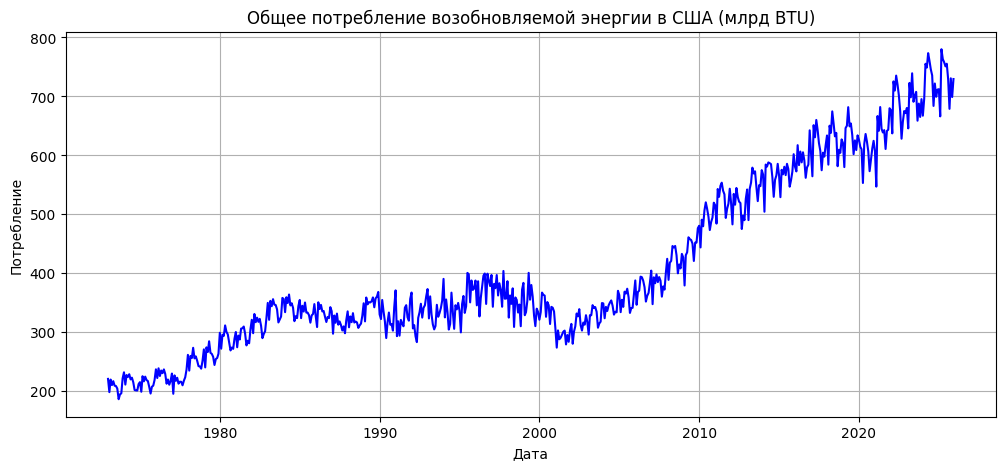

In [3]:
# 1.1 График ряда
plt.figure(figsize=(12,5))
plt.plot(total.index, total['total_consumption'], color='blue')
plt.title('Общее потребление возобновляемой энергии в США (млрд BTU)')
plt.xlabel('Дата')
plt.ylabel('Потребление')
plt.grid(True)
plt.show()

Результаты ADF теста для исходного ряда:
ADF статистика: 1.0604
p-value: 0.9949
Критические значения: {'1%': np.float64(-3.440992973242412), '5%': np.float64(-2.8662357332485353), '10%': np.float64(-2.569270733669741)}
Ряд нестационарен (не отвергаем H0)

Результаты ADF теста для логарифмической разности:
ADF статистика: -6.9635
p-value: 0.0000
Критические значения: {'1%': np.float64(-3.440992973242412), '5%': np.float64(-2.8662357332485353), '10%': np.float64(-2.569270733669741)}
Ряд стационарен (отвергаем H0)



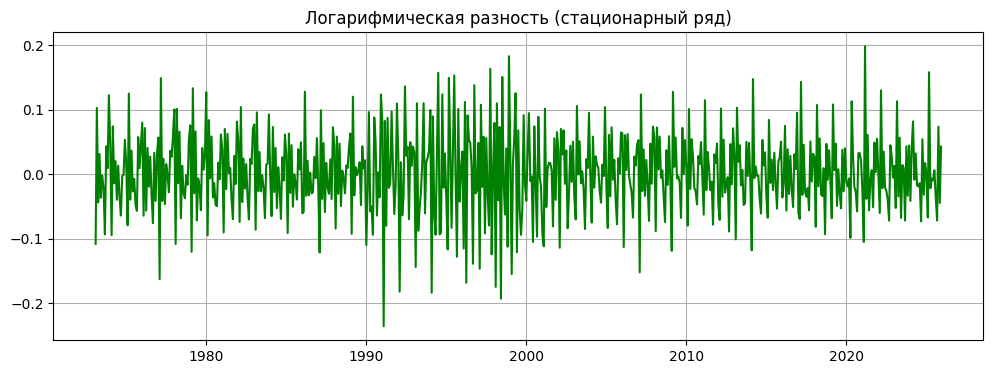

In [4]:
# 1.2 Проверка стационарности (тест Дики-Фуллера)
def adf_test(series, title=''):
    result = adfuller(series, autolag='AIC')
    print(f'Результаты ADF теста для {title}:')
    print(f'ADF статистика: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f'Критические значения: {result[4]}')
    if result[1] <= 0.05:
        print("Ряд стационарен (отвергаем H0)\n")
    else:
        print("Ряд нестационарен (не отвергаем H0)\n")

adf_test(total['total_consumption'], 'исходного ряда')

# 1.3 Приведение к стационарности (логарифмирование + первая разность)
total['log_cons'] = np.log(total['total_consumption'])
total['diff_log'] = total['log_cons'].diff().dropna()

adf_test(total['diff_log'].dropna(), 'логарифмической разности')

# 1.4 Визуализация преобразованного ряда
plt.figure(figsize=(12,4))
plt.plot(total.index, total['diff_log'], color='green')
plt.title('Логарифмическая разность (стационарный ряд)')
plt.grid(True)
plt.show()

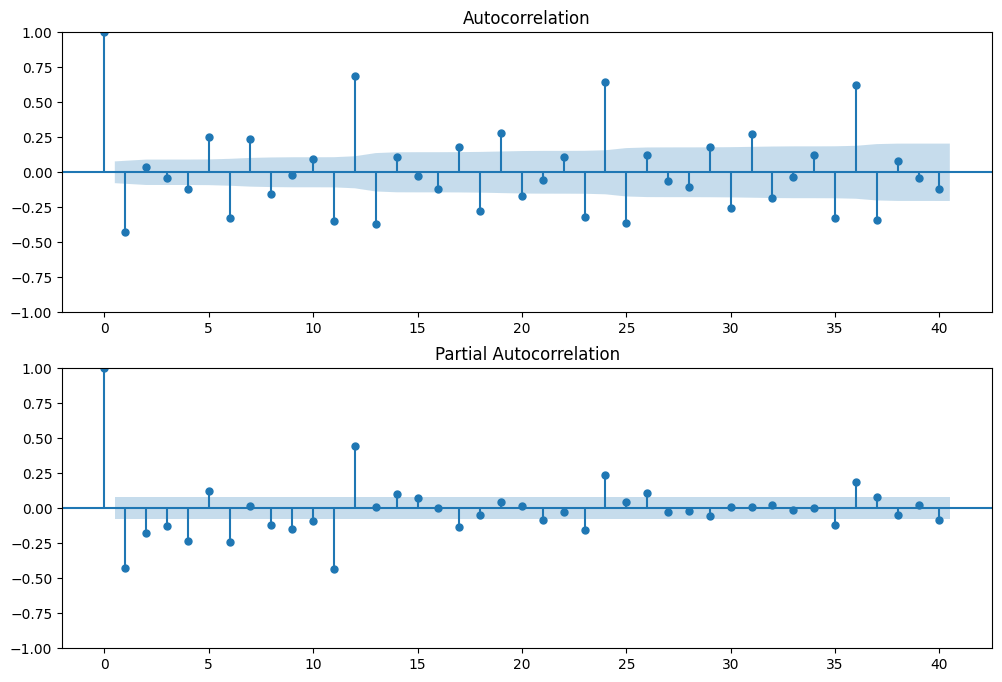

In [5]:
# 2.1 Построение ACF и PACF для стационарного ряда
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))
plot_acf(total['diff_log'].dropna(), ax=ax1, lags=40)
plot_pacf(total['diff_log'].dropna(), ax=ax2, lags=40)
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:      total_consumption   No. Observations:                  612
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2752.638
Date:                Sun, 17 May 2026   AIC                           5511.276
Time:                        17:37:15   BIC                           5524.521
Sample:                    01-01-1973   HQIC                          5516.428
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1845      0.054      3.412      0.001       0.079       0.291
ma.L1         -0.7519      0.039    -19.329      0.000      -0.828      -0.676
sigma2       478.8900     24.427     19.605      0.0

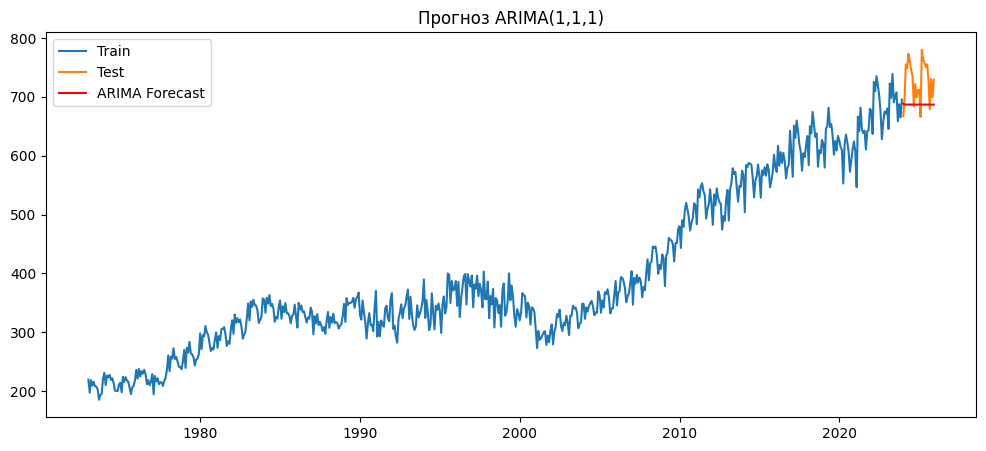

In [6]:
# Разделение на train/test (последние 24 месяца – тест)
train = total.iloc[:-24]
test = total.iloc[-24:]

# Обучение модели
model_arima = ARIMA(train['total_consumption'], order=(1,1,1))
model_arima_fit = model_arima.fit()
print(model_arima_fit.summary())

# Прогноз на тестовый интервал
forecast_arima = model_arima_fit.forecast(steps=24)

# Оценка качества
rmse_arima = np.sqrt(mean_squared_error(test['total_consumption'], forecast_arima))
mape_arima = mean_absolute_percentage_error(test['total_consumption'], forecast_arima)
print(f'RMSE (ARIMA): {rmse_arima:.2f}')
print(f'MAPE (ARIMA): {mape_arima:.4f}')

# Визуализация прогноза
plt.figure(figsize=(12,5))
plt.plot(train.index, train['total_consumption'], label='Train')
plt.plot(test.index, test['total_consumption'], label='Test')
plt.plot(test.index, forecast_arima, label='ARIMA Forecast', color='red')
plt.legend()
plt.title('Прогноз ARIMA(1,1,1)')
plt.show()

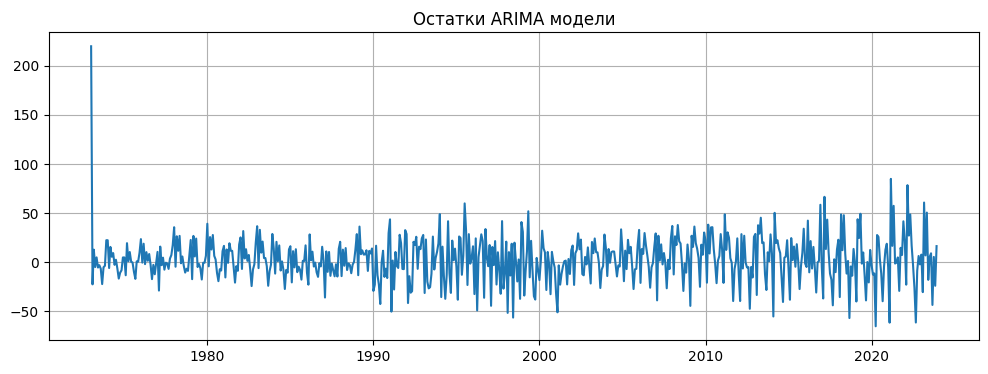

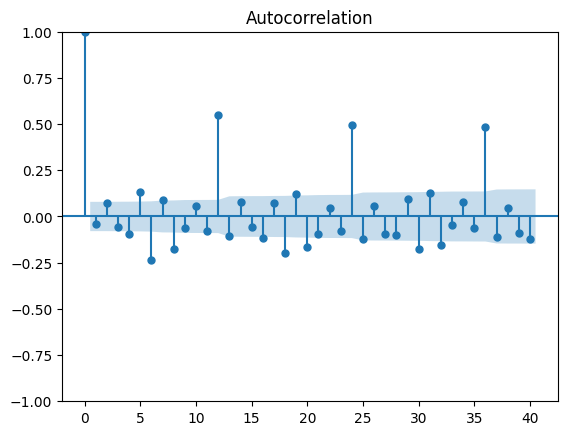

Тест Льюнга-Бокса для остатков:
       lb_stat     lb_pvalue
12  280.545416  5.645050e-53
24  525.593162  7.980890e-96


In [7]:
# 3.1 Остатки
residuals = model_arima_fit.resid
plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title('Остатки ARIMA модели')
plt.grid(True)
plt.show()

# ACF остатков
plot_acf(residuals, lags=40)
plt.show()

# Тест Льюнга-Бокса
lb_test = acorr_ljungbox(residuals, lags=[12,24], return_df=True)
print("Тест Льюнга-Бокса для остатков:")
print(lb_test)

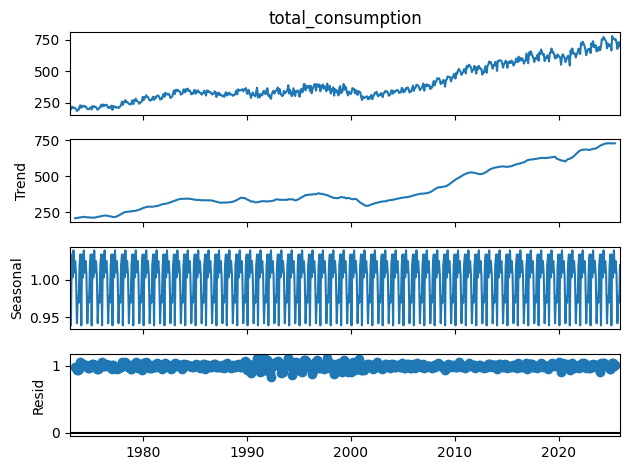

In [8]:
# 4.1 Проверка сезонности (декомпозиция)
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(total['total_consumption'], model='multiplicative', period=12)
decomp.plot()
plt.show()

In [9]:
# 4.2 Построение SARIMA (1,1,1)(1,1,1,12)
model_sarima = SARIMAX(train['total_consumption'], order=(1,1,1), seasonal_order=(1,1,1,12))
model_sarima_fit = model_sarima.fit()
print(model_sarima_fit.summary())

# Прогноз
forecast_sarima = model_sarima_fit.forecast(steps=24)

# Оценка качества
rmse_sarima = np.sqrt(mean_squared_error(test['total_consumption'], forecast_sarima))
mape_sarima = mean_absolute_percentage_error(test['total_consumption'], forecast_sarima)
print(f'RMSE (SARIMA): {rmse_sarima:.2f}')
print(f'MAPE (SARIMA): {mape_sarima:.4f}')

# Сравнение с ARIMA
print(f'Улучшение RMSE: {(rmse_arima - rmse_sarima)/rmse_arima*100:.2f}%')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                  total_consumption   No. Observations:                  612
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2451.606
Date:                            Sun, 17 May 2026   AIC                           4913.213
Time:                                    17:37:56   BIC                           4935.189
Sample:                                01-01-1973   HQIC                          4921.768
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3967      0.061      6.460      0.000       0.276       0.517
ma.L1         -0.7550      0.050   

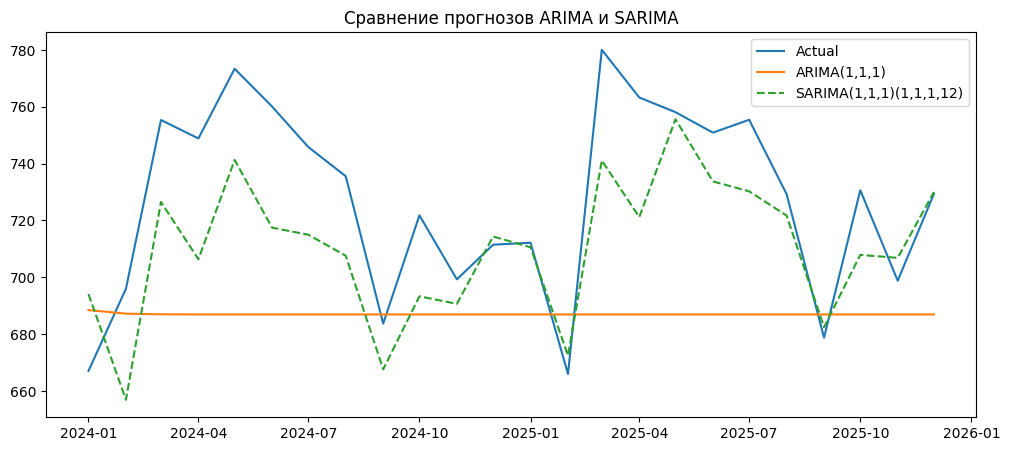

In [10]:
# Визуализация сравнения
plt.figure(figsize=(12,5))
plt.plot(test.index, test['total_consumption'], label='Actual')
plt.plot(test.index, forecast_arima, label='ARIMA(1,1,1)')
plt.plot(test.index, forecast_sarima, label='SARIMA(1,1,1)(1,1,1,12)', linestyle='--')
plt.legend()
plt.title('Сравнение прогнозов ARIMA и SARIMA')
plt.show()

In [13]:
# Подготовка внешних регрессоров
# 1. Потребление ветра (electric power, wind) – убедимся, что числовой тип
wind = df[(df['sector']=='electric power') & (df['energy_type']=='wind')]
wind = wind.set_index('date')['value_trillion_btu'].resample('MS').sum()
wind = wind.reindex(total.index, fill_value=0)
wind = wind.astype(float)  # явно приводим к float

# 2. Месяц года (от 1 до 12) – фиктивные переменные, преобразуем в int
month_dummies = pd.get_dummies(total.index.month, prefix='month', drop_first=True)
month_dummies = month_dummies.astype(int)  # bool -> int
month_dummies.index = total.index

# Объединяем регрессоры
exog = pd.concat([wind, month_dummies], axis=1)
# Убедимся, что все столбцы – числовые (float или int)
print(exog.dtypes.value_counts())  # Должно быть только float64 или int64

# Разделение на train/test (индексы уже синхронизированы)
exog_train = exog.loc[train.index]
exog_test = exog.loc[test.index]

# Построение SARIMAX
model_sarimax = SARIMAX(train['total_consumption'],
                        exog=exog_train,
                        order=(1,1,1),
                        seasonal_order=(1,1,1,12))
model_sarimax_fit = model_sarimax.fit()
print(model_sarimax_fit.summary())

# Прогноз с внешними факторами
forecast_sarimax = model_sarimax_fit.forecast(steps=24, exog=exog_test)

# Оценка
rmse_sarimax = np.sqrt(mean_squared_error(test['total_consumption'], forecast_sarimax))
mape_sarimax = mean_absolute_percentage_error(test['total_consumption'], forecast_sarimax)
print(f'RMSE (SARIMAX): {rmse_sarimax:.2f}')
print(f'MAPE (SARIMAX): {mape_sarimax:.4f}')

int64      11
float64     1
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                  total_consumption   No. Observations:                  612
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2417.359
Date:                            Sun, 17 May 2026   AIC                           4868.718
Time:                                    17:41:26   BIC                           4943.437
Sample:                                01-01-1973   HQIC                          4897.807
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
value_trillion_btu     1.1008      0.097     11.300      0.000       0.910       1.292
month_2    

In [12]:
# Используем pmdarima для автоматического подбора
auto_model = pm.auto_arima(train['total_consumption'],
                            seasonal=True, m=12,
                            start_p=0, max_p=3, start_q=0, max_q=3,
                            start_P=0, max_P=2, start_Q=0, max_Q=2,
                            trace=True, error_action='ignore',
                            suppress_warnings=True, stepwise=True)

print(auto_model.summary())
# Прогноз auto_arima
forecast_auto = auto_model.predict(n_periods=24)
rmse_auto = np.sqrt(mean_squared_error(test['total_consumption'], forecast_auto))
mape_auto = mean_absolute_percentage_error(test['total_consumption'], forecast_auto)
print(f'RMSE (auto_arima): {rmse_auto:.2f}')
print(f'MAPE (auto_arima): {mape_auto:.4f}')

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=5684.245, Time=0.06 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=5227.740, Time=0.66 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=5337.799, Time=3.07 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=5682.824, Time=0.14 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=5563.085, Time=0.11 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=5152.389, Time=3.64 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=5073.380, Time=3.65 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=5072.857, Time=0.84 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=5386.157, Time=0.40 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=5073.430, Time=2.30 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=5298.573, Time=1.55 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=5075.283, Time=4.00 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=5106.198, Time=0.46 sec
 ARIMA(2,1,0)(1,0,1)[12] intercept   : AIC=5027.697, Time=1.24 sec
 ARIMA(2,1,0)(0,0,1